In [1]:
import torch
import torch.nn as nn

# ═══════════════════════════════════════════════════════════
# 1. Physics-Informed Module (Implicit PNA Solver)
# ═══════════════════════════════════════════════════════════

class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    ─────────────────────────────────────────────────────
    Forward : Bisection Method로 인장력 = 압축력 평형점(y_pna) 탐색
    Backward: Implicit Function Theorem(IFT)으로 ∂y_pna/∂coords 계산 후
              chain-rule을 통해 ∂Mp/∂coords 를 GNN까지 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        """
        coords    : [N, 2]  (x, y)
        t         : [N, 1]  두께
        fy        : [N, 1]  항복강도
        edge_index: [2, E]  (사용 안 하지만 인터페이스 유지)
        n_iter    : bisection 반복 횟수
        """
        # ── 1. Bisection으로 PNA 탐색 (no grad) ──
        with torch.no_grad():
            y = coords[:, 1]                       # [N]
            t_flat = t.squeeze(-1)                 # [N]
            fy_flat = fy.squeeze(-1)               # [N]

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                # 인장(위쪽) / 압축(아래쪽) 힘
                F_tens = torch.sum(t_flat * fy_flat * torch.clamp(y - y_mid, min=0.0))
                F_comp = torch.sum(t_flat * fy_flat * torch.clamp(y_mid - y, min=0.0))

                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)           # scalar tensor

        # ── 2. 전소성 모멘트 Mp = Σ A_i · fy_i · |y_i − y_pna| ──
        d = torch.abs(coords[:, 1] - y_pna)       # [N]
        area = t_flat                              # 단위 길이당 면적
        mp_pred = torch.sum(area * fy_flat * d)    # scalar

        # backward 에 필요한 텐서 저장
        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        """
        Implicit Function Theorem 적용
        ──────────────────────────────
        평형 조건  g(y_pna, coords) = F_tens − F_comp = 0

        IFT에 의해:
            ∂y_pna/∂y_i = − (∂g/∂y_i) / (∂g/∂y_pna)

        ∂Mp/∂y_i = A_i·fy_i·sign(y_i−y_pna)
                  + Σ_j A_j·fy_j·(−sign(y_j−y_pna)) · (∂y_pna/∂y_i)

        두 번째 항이 IFT 보정 항으로, PNA 이동에 의한 간접 효과를 반영합니다.
        """
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)   # scalar

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)

        s = torch.sign(y - y_pna)      # +1(인장), −1(압축)

        # ── ∂g/∂y_pna  (평형식의 y_pna에 대한 미분) ──
        #  g = Σ t·fy·clamp(y−y_pna,0) − Σ t·fy·clamp(y_pna−y,0)
        #  ∂g/∂y_pna = −Σ t·fy · 1[y>y_pna] − Σ t·fy · 1[y<y_pna]
        #            = −Σ t·fy  (y_pna 정확히 위의 노드 무시)
        dg_dy_pna = -torch.sum(t_flat * fy_flat)   # scalar (항상 음수)

        # ── ∂g/∂y_i ──
        #  i번째 노드가 인장(y_i>y_pna) → ∂g/∂y_i = +t_i·fy_i
        #  i번째 노드가 압축(y_i<y_pna) → ∂g/∂y_i = −t_i·fy_i  ⟹  = s_i · t_i · fy_i
        dg_dy = s * t_flat * fy_flat               # [N]

        # ── IFT: ∂y_pna/∂y_i = −dg_dy / dg_dy_pna ──
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)  # [N]

        # ── ∂Mp/∂y_i (직접 항 + IFT 보정 항) ──
        direct = t_flat * fy_flat * s                               # [N]
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy     # [N]
        dMp_dy = direct + indirect                                  # [N]

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None   # n_iter 추가로 5개


def calculate_mpl(coords, t, fy, edge_index):
    """Wrapper: ImplicitPNASolver.apply 호출"""
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)

In [2]:
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, LayerNorm

# ═══════════════════════════════════════════════════════════
#  2. C-GDN (Constraint-aware Graph Deformation Network)
# ═══════════════════════════════════════════════════════════
#  - 표준 템플릿(Base Section)을 목표 Mp에 맞춰 **변형**하는 구조
#  - FiLM 레이어로 매 GATv2 블록에 Mp 조건 주입
#  - Hard constraint: 고정점 마스킹
# ═══════════════════════════════════════════════════════════

class FiLMGenerator(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM)
    target_mp [B, 1] → (gamma, beta) [B, hidden]
    """
    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )

    def forward(self, target_mp):
        """target_mp: [1, 1] or [B, 1]"""
        out = self.net(target_mp)                       # [B, 2H]
        gamma, beta = torch.chunk(out, 2, dim=-1)       # [B, H] each
        return gamma, beta


class CGDNBlock(nn.Module):
    """
    단일 Message-Passing 블록
    GATv2Conv → FiLM modulation → LayerNorm → GELU → Residual
    """
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)

        # FiLM conditioning: γ ⊙ h + β
        h = gamma * h + beta

        h = self.norm(h)
        h = F.gelu(h)
        h = h + h_res   # residual
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network

    입력 노드 특징 (R^6):
        [x, y, is_fixed, layer_id, t, fy]

    엣지 특징 (R^4):
        [선분 길이, 각도, 레이어 ID, 플랜지 여부]

    조건부 입력:
        target_mp  (목표 전소성 모멘트)
    """

    def __init__(
        self,
        in_channels: int = 6,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,     # 최대 변위 클리핑 (mm)
    ):
        super().__init__()
        self.max_displacement = max_displacement

        # 1. Node Encoder ─────────────────────────
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        # 2. FiLM Generator (Mp 조건 주입) ────────
        self.film_gen = FiLMGenerator(hidden_channels)

        # 3. GATv2 Message-Passing Blocks ─────────
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        # 4. Coordinate Decoder ───────────────────
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),               # 출력: (Δx, Δy)
        )

    def forward(self, x, edge_index, edge_attr, target_mp, is_fixed_mask):
        """
        Parameters
        ----------
        x             : [N, 6]   노드 특징
        edge_index    : [2, E]
        edge_attr     : [E, 4]   엣지 특징
        target_mp     : [1, 1]   목표 전소성 모멘트
        is_fixed_mask : [N, 1]   고정점 Boolean 마스크

        Returns
        -------
        new_coords    : [N, 2]   변형 후 좌표
        delta_coords  : [N, 2]   변위 벡터
        """
        # ── Encode ──
        h = self.node_encoder(x)

        # ── FiLM parameters (한 번 생성, 모든 블록에 공유) ──
        gamma, beta = self.film_gen(target_mp)          # [1, H]

        # ── Message Passing ──
        for block in self.blocks:
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── Decode displacement ──
        delta_coords = self.decoder(h)                  # [N, 2]

        # 변위 클리핑 (안정성)
        delta_coords = torch.clamp(delta_coords,
                                   -self.max_displacement,
                                    self.max_displacement)

        # ── Hard Constraint: 고정점은 변위 = 0 ──
        delta_coords = delta_coords * (~is_fixed_mask).float()

        # ── 최종 좌표 = Base 좌표 + Δ ──
        new_coords = x[:, :2] + delta_coords

        return new_coords, delta_coords

/home/hyu31/miniforge3/envs/GNN/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Initial Base Shape Mp: 662067.8
C-GDN Training | Target Mp: 800000.0
Epoch 000 | Loss: 120.3959 | Mp: 657103.9 / 800000.0
Epoch 010 | Loss: 42.9225 | Mp: 667508.2 / 800000.0
Epoch 020 | Loss: 41.8685 | Mp: 670084.0 / 800000.0
Epoch 030 | Loss: 40.8132 | Mp: 672722.1 / 800000.0
Epoch 040 | Loss: 36.9703 | Mp: 682832.8 / 800000.0
Epoch 050 | Loss: 25.5944 | Mp: 720083.7 / 800000.0
Epoch 060 | Loss: 16.2266 | Mp: 812523.1 / 800000.0
Epoch 070 | Loss: 15.8996 | Mp: 794467.2 / 800000.0
Epoch 080 | Loss: 15.8623 | Mp: 799439.4 / 800000.0
Epoch 090 | Loss: 15.8655 | Mp: 800910.2 / 800000.0
Epoch 100 | Loss: 15.8675 | Mp: 796120.5 / 800000.0
Epoch 110 | Loss: 15.8611 | Mp: 800697.9 / 800000.0
Epoch 120 | Loss: 15.8553 | Mp: 797688.0 / 800000.0
Epoch 130 | Loss: 15.8517 | Mp: 799225.1 / 800000.0
Epoch 140 | Loss: 15.8486 | Mp: 798615.2 / 800000.0


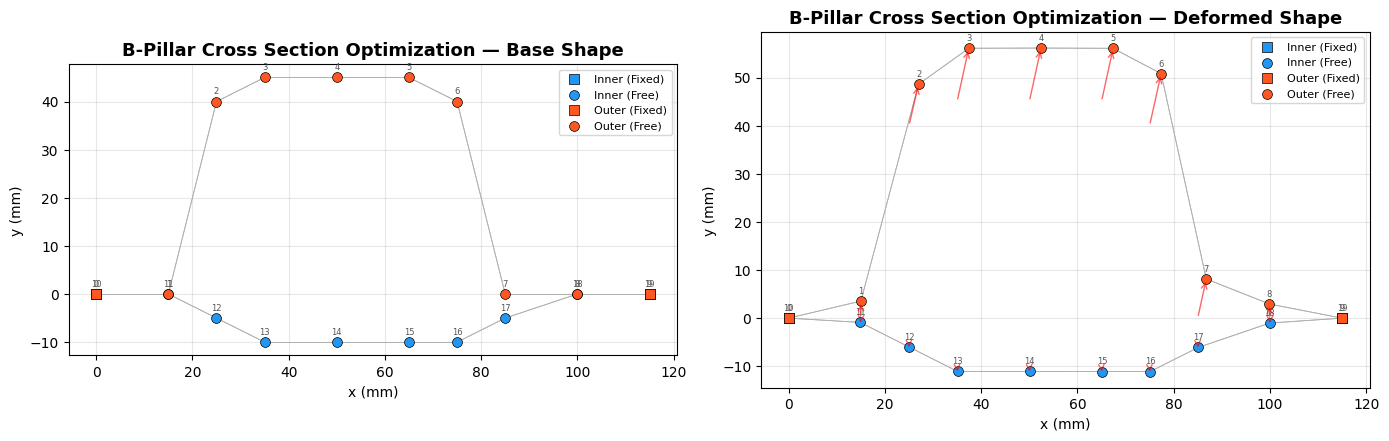

In [3]:
import torch.optim as optim
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import numpy as np

# ═══════════════════════════════════════════════════════════
# 3. Loss Functions & Train Step
# ═══════════════════════════════════════════════════════════
def compute_smoothness_loss(new_coords, edge_index):
    src, dst = edge_index
    diff = new_coords[src] - new_coords[dst]
    return torch.mean(torch.norm(diff, dim=1) ** 2)

def compute_collision_loss(new_coords, layer_ids, margin=0.5):
    inner_mask = (layer_ids == 0)
    outer_mask = (layer_ids == 1)
    if inner_mask.sum() == 0 or outer_mask.sum() == 0:
        return torch.tensor(0.0, device=new_coords.device)

    inner_y = new_coords[inner_mask, 1]
    outer_y = new_coords[outer_mask, 1]
    gap_violation = torch.clamp(inner_y.max() - outer_y.min() + margin, min=0.0)
    return gap_violation ** 2

def compute_mass_loss(new_coords, t, edge_index):
    src, dst = edge_index
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)
    return area

def train_step(model, data, optimizer, target_mp_value,
               w_phys=1.0, w_smooth=0.1, w_mass=0.01,
               w_collision=1.0, w_fix=10.0):
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr

    is_fixed_mask = x[:, 2].bool().unsqueeze(1)
    layer_ids     = x[:, 3] 
    t             = x[:, 4].unsqueeze(1)
    fy            = x[:, 5].unsqueeze(1)

    target_mp = torch.tensor([[target_mp_value]], dtype=torch.float32, device=x.device)

    new_coords, delta_coords = model(x, edge_index, edge_attr, target_mp, is_fixed_mask)
    pred_mp = calculate_mpl(new_coords, t, fy, edge_index)

    l_phys = ((pred_mp - target_mp) / target_mp) ** 2
    l_smooth = compute_smoothness_loss(new_coords, edge_index)
    l_mass = compute_mass_loss(new_coords, t, edge_index)
    l_collision = compute_collision_loss(new_coords, layer_ids)
    
    fixed_nodes = is_fixed_mask.squeeze()
    l_fix = torch.sum(torch.norm(delta_coords[fixed_nodes], dim=1)) if fixed_nodes.any() else torch.tensor(0.0, device=x.device)

    loss = (w_phys * l_phys + w_smooth * l_smooth + w_mass * l_mass + 
            w_collision * l_collision + w_fix * l_fix)

    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "pred_mp": pred_mp.item(),
        "l_phys": l_phys.item(),
        "l_smooth": l_smooth.item(),
        "l_mass": l_mass.item(),
        "l_collision": l_collision.item(),
        "l_fix": l_fix.item() if isinstance(l_fix, torch.Tensor) else l_fix,
        "new_coords": new_coords.detach(),
    }

# ═══════════════════════════════════════════════════════════
# 4. Data Generation
# ═══════════════════════════════════════════════════════════
def create_bpillar_base_model(device):
    outer_coords = [
        [0.0, 0.0], [15.0, 0.0], [25.0, 40.0], [35.0, 45.0], [50.0, 45.0],
        [65.0, 45.0], [75.0, 40.0], [85.0, 0.0], [100.0, 0.0], [115.0, 0.0]
    ]
    inner_coords = [
        [0.0, 0.0], [15.0, 0.0], [25.0, -5.0], [35.0, -10.0], [50.0, -10.0],
        [65.0, -10.0], [75.0, -10.0], [85.0, -5.0], [100.0, 0.0], [115.0, 0.0]
    ]
    
    coords = torch.tensor(outer_coords + inner_coords, dtype=torch.float32)
    num_nodes = coords.shape[0]

    is_fixed = torch.zeros(num_nodes, dtype=torch.float32)
    is_fixed[[0, 9, 10, 19]] = 1.0 
    
    layer_id = torch.zeros(num_nodes, dtype=torch.float32)
    layer_id[0:10] = 1.0 
    
    t = torch.zeros(num_nodes, dtype=torch.float32)
    t[0:10] = 1.5 
    t[10:20] = 1.2 
    
    fy = torch.zeros(num_nodes, dtype=torch.float32)
    fy[0:10] = 1500.0 
    fy[10:20] = 800.0 
    
    x = torch.cat([coords, is_fixed.unsqueeze(1), layer_id.unsqueeze(1), 
                   t.unsqueeze(1), fy.unsqueeze(1)], dim=1).to(device)

    src, dst = [], []
    for i in range(9):
        src.extend([i, i+1])
        dst.extend([i+1, i])
    for i in range(10, 19):
        src.extend([i, i+1])
        dst.extend([i+1, i])
        
    flange_pairs = [(0, 10), (1, 11), (8, 18), (9, 19)]
    for p in flange_pairs:
        src.extend([p[0], p[1]])
        dst.extend([p[1], p[0]])
        
    edge_index = torch.tensor([src, dst], dtype=torch.long).to(device)

    num_edges = edge_index.shape[1]
    edge_attr = torch.zeros((num_edges, 4), dtype=torch.float32).to(device)
    for idx in range(num_edges):
        p1 = coords[edge_index[0, idx]]
        p2 = coords[edge_index[1, idx]]
        edge_attr[idx, 0] = torch.norm(p1 - p2)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# ═══════════════════════════════════════════════════════════
# 5. Visualization
# ═══════════════════════════════════════════════════════════
def visualize_section(coords, edge_index, x_features, title="B-Pillar Cross Section",
                      deformed_coords=None, figsize=(14, 7)):
    is_fixed  = x_features[:, 2].cpu().numpy().astype(bool)
    layer_ids = x_features[:, 3].cpu().numpy().astype(int)
    coords_np = coords.cpu().detach().numpy()
    ei = edge_index.cpu().numpy()

    n_plots = 2 if deformed_coords is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]

    def _draw(ax, pts, subtitle):
        for i in range(ei.shape[1]):
            s, d = ei[0, i], ei[1, i]
            ax.plot([pts[s, 0], pts[d, 0]], [pts[s, 1], pts[d, 1]],
                    color='#b0b0b0', linewidth=0.6, zorder=1)

        colors_map = {0: '#2196F3', 1: '#FF5722'}   
        marker_map = {True: 's', False: 'o'}        
        label_map  = {True: 'Fixed', False: 'Free'}
        layer_name = {0: 'Inner', 1: 'Outer'}

        for lid in [0, 1]:
            for fix in [True, False]:
                mask = (layer_ids == lid) & (is_fixed == fix)
                if not mask.any():
                    continue
                lbl = f'{layer_name[lid]} ({label_map[fix]})'
                ax.scatter(pts[mask, 0], pts[mask, 1],
                           c=colors_map[lid], marker=marker_map[fix],
                           s=50, edgecolors='k', linewidths=0.5,
                           zorder=3, label=lbl)

        for i in range(len(pts)):
            ax.annotate(str(i), (pts[i, 0], pts[i, 1]),
                        fontsize=6, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color='#555555')

        ax.set_title(subtitle, fontsize=13, fontweight='bold')
        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    _draw(axes[0], coords_np, f'{title} — Base Shape')

    if deformed_coords is not None:
        def_np = deformed_coords.cpu().detach().numpy()
        _draw(axes[1], def_np, f'{title} — Deformed Shape')

        for i in range(len(coords_np)):
            dx = def_np[i, 0] - coords_np[i, 0]
            dy = def_np[i, 1] - coords_np[i, 1]
            if np.sqrt(dx**2 + dy**2) > 1e-4:
                axes[1].annotate('', xy=(def_np[i, 0], def_np[i, 1]),
                                 xytext=(coords_np[i, 0], coords_np[i, 1]),
                                 arrowprops=dict(arrowstyle='->', color='red', lw=1.0, alpha=0.6))

    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════
# 6. Main Execution
# ═══════════════════════════════════════════════════════════
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    model = CGDN(in_channels=6, hidden_channels=128, num_layers=4).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    data = create_bpillar_base_model(device)
    
    # 베이스 모델의 초기 Mp 계산을 위해 한번 측정해봅니다.
    initial_mp = calculate_mpl(data.x[:, :2], data.x[:, 4].unsqueeze(1), data.x[:, 5].unsqueeze(1), data.edge_index)
    print(f"Initial Base Shape Mp: {initial_mp.item():.1f}")
    
    # 목표 Mp 설정 (초기 Mp보다 약 20% 높게 설정하여 확장을 유도)
    # target_mp_req = initial_mp.item() * 1.2
    target_mp_req = 800000.0

    print("=" * 60)
    print(f"C-GDN Training | Target Mp: {target_mp_req:.1f}")
    print("=" * 60)
    
    for epoch in range(150):
        info = train_step(model, data, optimizer, target_mp_req,
            w_phys=1000.0, 
            w_smooth=0.01, 
            w_mass=0.0001, 
            w_collision=50.0, 
            w_fix=100.0
        )
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {info['loss']:.4f} | Mp: {info['pred_mp']:.1f} / {target_mp_req:.1f}")

    # 최종 결과 시각화
    base_coords = data.x[:, :2]
    deformed = info['new_coords']

    visualize_section(
        coords=base_coords,
        edge_index=data.edge_index,
        x_features=data.x,
        title='B-Pillar Cross Section Optimization',
        deformed_coords=deformed,
    )